<img src="https://webna.ir/wp-content/uploads/2018/08/%D9%85%DA%A9%D8%AA%D8%A8-%D8%AE%D9%88%D9%86%D9%87.png" width=50% />

<div class="alert alert-block alert-success">
    <h1 align="center">Machine Learning in Python</h1>
    <h3 align="center">Mini Project2 - Bike Sharing</h3>
</div>

<img src = "https://storage.googleapis.com/kaggle-competitions/kaggle/3948/media/bikes.png" width=80%>

## Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Prepare Data

In [56]:
data = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [57]:
data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


## EDA

In [58]:
data.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [64]:
data.sort_values(by="count",ascending=False).head(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
9345,2012-09-12 18:00:00,3,0,1,1,27.06,31.060,44,16.9979,91,886,977
9320,2012-09-11 17:00:00,3,0,1,1,28.70,31.820,28,0.0000,168,802,970
9297,2012-09-10 18:00:00,3,0,1,1,25.42,31.060,35,19.9995,111,857,968
9752,2012-10-10 17:00:00,4,0,1,1,23.78,27.275,43,15.0013,91,857,948
9896,2012-10-16 17:00:00,4,0,1,1,21.32,25.000,39,12.9980,104,839,943
9344,2012-09-12 17:00:00,3,0,1,1,28.70,31.820,41,19.9995,114,811,925
9584,2012-10-03 17:00:00,4,0,1,1,28.70,32.575,65,0.0000,84,833,917
9608,2012-10-04 17:00:00,4,0,1,1,28.70,32.575,51,15.0013,112,789,901
9632,2012-10-05 17:00:00,4,0,1,1,28.70,31.820,42,11.0014,158,742,900
8984,2012-08-16 17:00:00,3,0,1,1,33.62,36.365,34,12.9980,130,767,897


In [74]:
data[["holiday","count"]].groupby("holiday").mean().reset_index()

,holiday,count
0,0,191.741655
1,1,185.877814


In [75]:
data[["season","count"]].groupby("season").mean().reset_index()

,season,count
0,1,116.343261
1,2,215.251372
2,3,234.417124
3,4,198.988296


## Data Preprocessing

In [76]:
data.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [77]:
data["datetime"] = pd.to_datetime(data["datetime"])

In [182]:
test["datetime"] = pd.to_datetime(test["datetime"])

In [85]:
data["year"] = data["datetime"].dt.year
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["dayofweek"] = data["datetime"].dt.dayofweek
data["hour"] = data["datetime"].dt.hour

In [183]:
test["year"] = test["datetime"].dt.year
test["month"] = test["datetime"].dt.month
test["day"] = test["datetime"].dt.day
test["dayofweek"] = test["datetime"].dt.dayofweek
test["hour"] = test["datetime"].dt.hour

## Strorytelling - Visualization

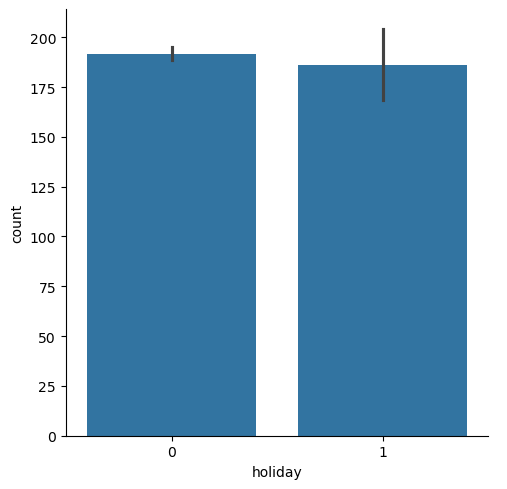

In [79]:
sns.catplot(data,x = "holiday", y = "count",kind="bar")

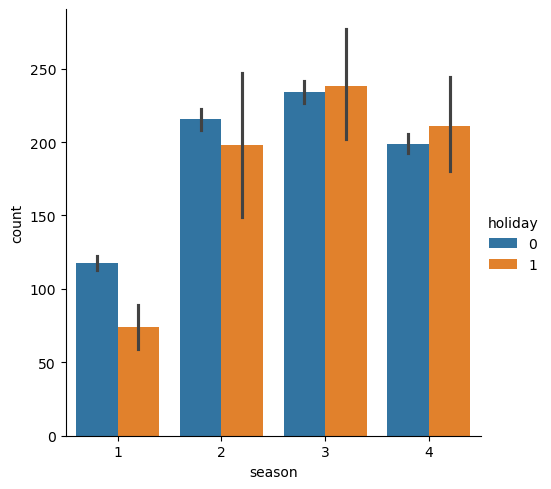

In [80]:
sns.catplot(data,x = "season", y = "count",kind="bar",hue="holiday")

<Axes: xlabel='hour', ylabel='count'>

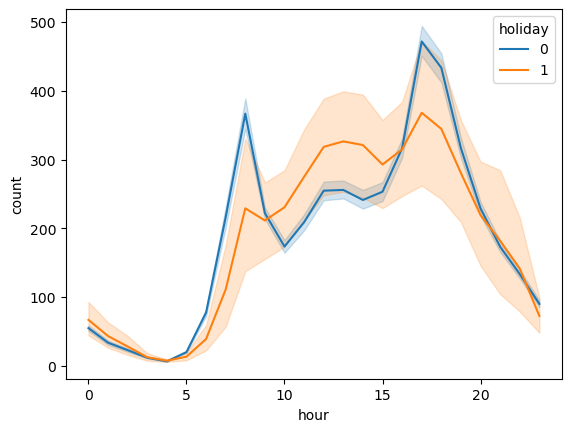

In [91]:
sns.lineplot(data,x = "hour", y = "count",hue="holiday")

<Axes: xlabel='temp', ylabel='count'>

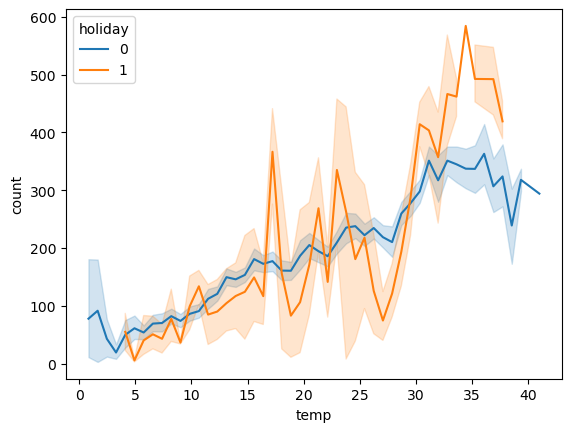

In [92]:
sns.lineplot(data,x = "temp", y = "count",hue="holiday")

<Axes: xlabel='humidity', ylabel='count'>

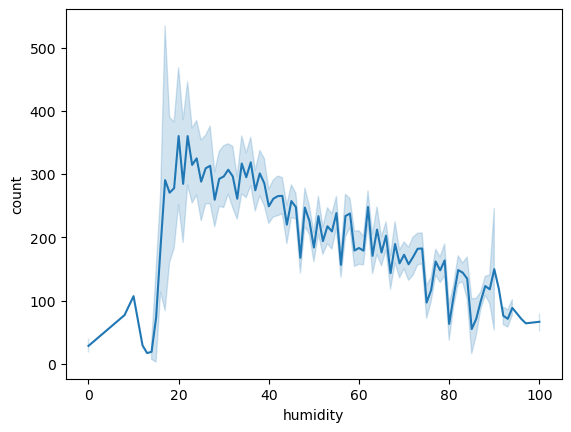

In [94]:
sns.lineplot(data,x = "humidity", y = "count")

<Axes: xlabel='windspeed', ylabel='count'>

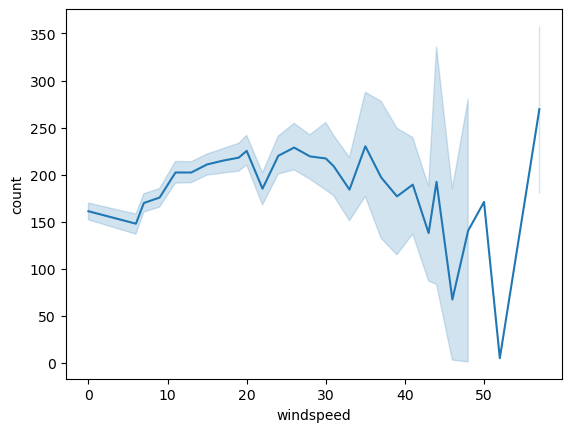

In [96]:
sns.lineplot(data,x = "windspeed", y = "count")

<Axes: >

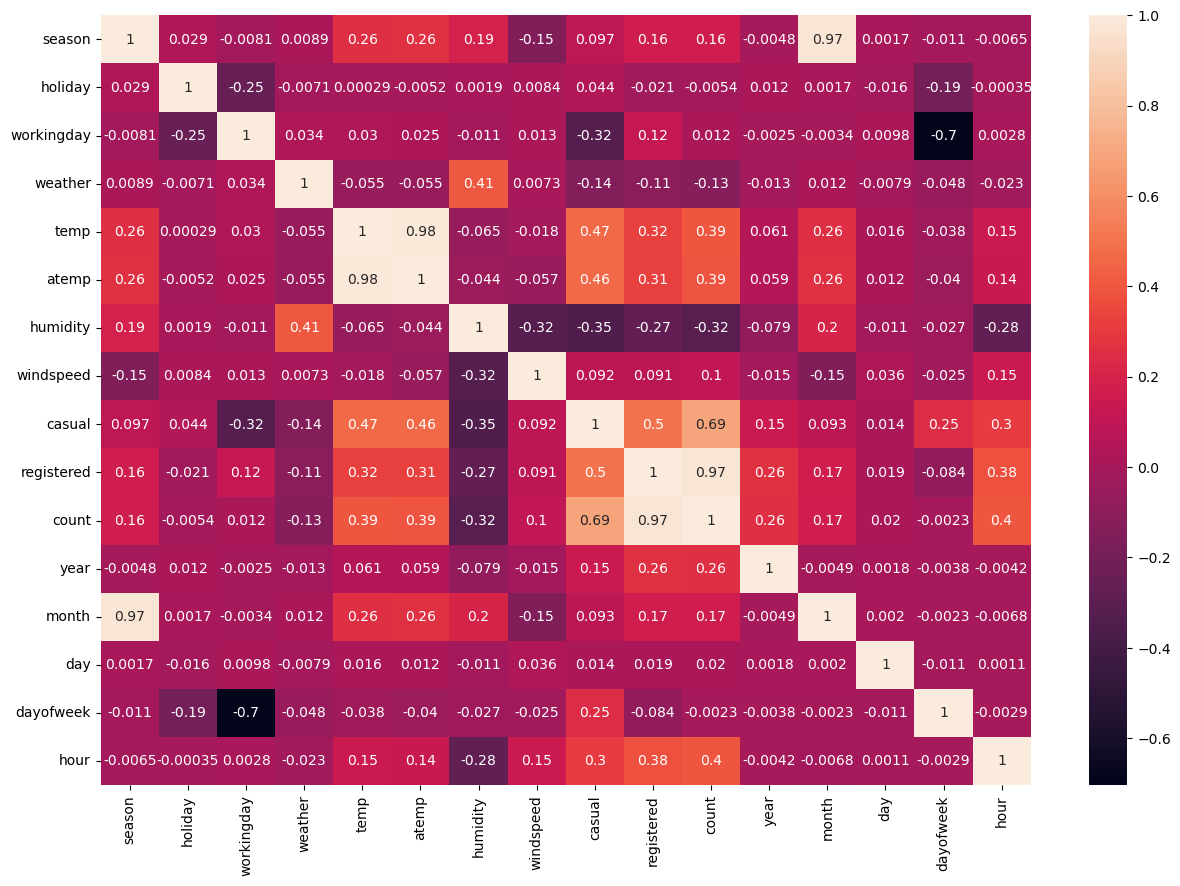

In [97]:
plt.figure(figsize=(15,10))
sns.heatmap(data.drop(columns="datetime").corr(),annot=True)

## Train your model (Regression)

In [174]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

In [161]:
X_train , X_test , Y_train , Y_test = train_test_split(data.drop(columns=["datetime","casual","registered","count"]),data["count"],test_size=.2)

In [162]:
model = LinearRegression().fit(X_train,Y_train)

In [163]:
model.score(X_train,Y_train)

0.38769152630459636

In [164]:
model.score(X_test,Y_test)

0.395106983473935

In [165]:
poly = PolynomialFeatures(3)
X_trainp = poly.fit_transform(X_train)

In [166]:
pmodel = LinearRegression().fit(X_trainp,Y_train)

In [167]:
pmodel.score(X_trainp,Y_train)

0.6593165729981967

In [168]:
pmodel.score(poly.fit_transform(X_test),Y_test)

0.6131889013767876

In [171]:
r2_score(Y_train,pmodel.predict(X_trainp))

0.6593165729981967

In [172]:
mean_absolute_error(Y_train,pmodel.predict(X_trainp))

75.91677523955289

In [173]:
mean_squared_error(Y_train,pmodel.predict(X_trainp))

11288.11502372373

In [175]:
rfr = RandomForestRegressor().fit(X_train,Y_train)

In [176]:
rfr.score(X_train,Y_train)

0.9932131096952974

In [177]:
rfr.score(X_test,Y_test)

0.9476579186003237

In [178]:
r2_score(Y_train,rfr.predict(X_train))

0.9932131096952974

In [179]:
mean_absolute_error(Y_train,rfr.predict(X_train))

9.141002526412494

In [180]:
mean_squared_error(Y_train,rfr.predict(X_train))

224.87503747129074

## Test Result

In [192]:
submission = rfr.predict(test.drop(columns="datetime"))

In [193]:
submission = submission.astype(int)

In [194]:
sub = pd.DataFrame({"datetime":test["datetime"],"count":submission})

In [195]:
sub.to_csv("Submission.csv",index=False)

## Send us the Result (Maktabkhoone)